# Phase 1
Training the teacher to avoid obstacles and get to the goal efficiently/quickly

In [1]:
%cd ..
# need to be able to see environment

/Users/charlottewoodrum/Documents/GitHub/gymnasium-rl/gridworld_v1


In [2]:
%pip install torch


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install tqdm
%pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
os.chdir('gridworld_v1') # don't ask me why its not in the right directory...

In [4]:
# imports
from environment.custom_environment import GridWorldBase, TeacherWrapper
from agents.agents import TeacherAgent, ExperienceReplay
import tqdm
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# initialization
grid_size = 5
learning_rate = 0.001
initial_epsilon = 1
epsilon_decay = 0.99
final_epsilon = 0.01
num_filters_first_layer = 8
discount_factor = 0.95

base_env = GridWorldBase(grid_size, 0, 10)
env = TeacherWrapper(base_env, None, [-1.0, 0.0])
agent = TeacherAgent(base_env, learning_rate, initial_epsilon, epsilon_decay, final_epsilon, discount_factor, num_filters_first_layer)
experience_replay = ExperienceReplay(capacity=5000, batch_size=32)

Using mps device


In [ ]:
# training
episodes = 2000
max_steps = 50

episode_total_rewards = []
losses = []
lengths = []

pbar = tqdm.tqdm(range(episodes), desc="Training")

for episode in pbar: 
    obs, info = env.reset()
    state = base_env.make_grid()
    episode_reward = 0

    for step in range(max_steps): 
        action = agent.get_action(state)
        obs, reward, terminated, truncated, info = env.step(action)
        next_state = base_env.make_grid()

        experience_replay.add_experience(state, action, reward, next_state, terminated or truncated)
        if terminated or truncated: 
            lengths.append(step) # number of steps taken
            break

        if experience_replay.can_provide_sample(): 
            experiences = experience_replay.sample_batch()
            loss = agent.learn(experiences)
            losses.append(loss)
        
        episode_reward += reward
        state = next_state

        pbar.set_postfix(epsilon=f"{agent.epsilon:.3f}", steps=step)
    
        if episode % 100 == 0:
            pass # in the future I want to record some extra info here or smth
    
    episode_total_rewards.append(episode_reward)

torch.save(agent.model.state_dict(), f'models/model_{grid_size}.pt')

Training: 100%|██████████| 2000/2000 [16:28<00:00,  2.02it/s, epsilon=0.010, steps=49]


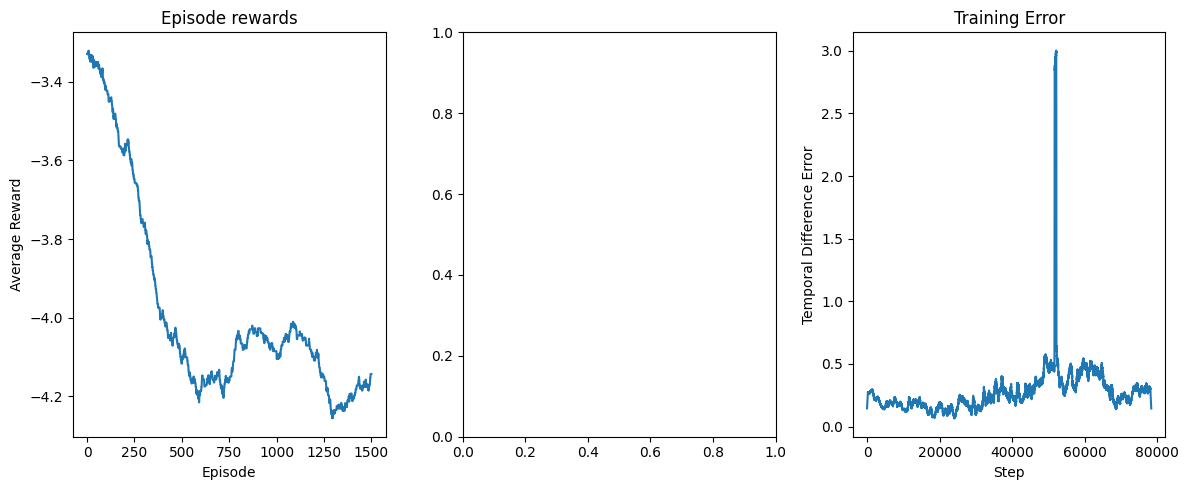

In [14]:
# https://gymnasium.farama.org/introduction/train_agent/
def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    episode_total_rewards,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")
''' didn't record this time unfortunately, but will next time
# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    lengths,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")
'''

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    losses,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [15]:
# test

agent.epsilon = 0
obs, info = env.reset()
state = base_env.make_grid()
base_env.render()

total_reward = 0
for step in range(max_steps):
    action = agent.get_action(state)  # use epsilon=0 for pure exploitation
    obs, reward, terminated, truncated, info = env.step(action)
    next_state = base_env.make_grid()
    total_reward += reward

    print(f"Step {step} | Action: {action} | Reward: {reward}")
    base_env.render()

    state = next_state
    if terminated or truncated:
        print(f"Done in {step+1} steps | Total reward: {total_reward}")
        break

['.', '.', '.', '.', '.']
['.', '.', '.', '.', '.']
['.', '.', 'S', '.', '.']
['G', '.', '.', '.', '.']
['.', '.', '.', '.', '.']

Step 0 | Action: 0 | Reward: -0.1
['.', '.', '.', '.', '.']
['.', '.', '.', '.', '.']
['.', '.', 'S', 'T', '.']
['G', '.', '.', '.', '.']
['.', '.', '.', '.', '.']

Step 1 | Action: 1 | Reward: -0.1
['.', '.', '.', '.', '.']
['.', '.', '.', 'T', '.']
['.', '.', 'S', '.', '.']
['G', '.', '.', '.', '.']
['.', '.', '.', '.', '.']

Step 2 | Action: 1 | Reward: -0.1
['.', '.', '.', 'T', '.']
['.', '.', '.', '.', '.']
['.', '.', 'S', '.', '.']
['G', '.', '.', '.', '.']
['.', '.', '.', '.', '.']

Step 3 | Action: 1 | Reward: -0.1
['.', '.', '.', 'T', '.']
['.', '.', '.', '.', '.']
['.', '.', 'S', '.', '.']
['G', '.', '.', '.', '.']
['.', '.', '.', '.', '.']

Step 4 | Action: 1 | Reward: -0.1
['.', '.', '.', 'T', '.']
['.', '.', '.', '.', '.']
['.', '.', 'S', '.', '.']
['G', '.', '.', '.', '.']
['.', '.', '.', '.', '.']

Step 5 | Action: 1 | Reward: -0.1
['.', '.',